# CREATED BY: FILIPY
### SVM CLASSIFIER FOR IMAGE CLASSIFICATION PROBLEM
### LAST EDIT: 17/02/2026

In [1]:
import pandas as pd
#Downgraded numpy for compatibility purposes
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split

/home/filipy/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def reader(path_train):
    try:
        if type(path_train) != str:
            raise ValueError
            
        p = Path(path_train)
        if p.exists():
            #OPEN THE FILE
            with open(p, 'rb') as data:
                #UNPICKLE THE FILE
                df_temp = pickle.load(data, encoding='bytes')
                #TAKE JUST WHAT WE NEED
                X = df_temp[b'data']
                Y = np.array(df_temp[b'labels'])
                data.close()
                #Reshape features and transform them into dataframes
            X = X.reshape(10000,3072)
            y = Y.reshape(10000)
            y = pd.DataFrame(data=y)
            X = pd.DataFrame(data=X)

            return X, y
        else:
            raise FileNotFoundError(path_train)
        return X, Y
    except Exception as e:
        raise e

In [3]:
X1, Y1 = reader('dataset/data_batch_1')
X2, Y2 = reader('dataset/data_batch_2')
X3, Y3 = reader('dataset/data_batch_3')
X4, Y4 = reader('dataset/data_batch_4')
X5, Y5 = reader('dataset/data_batch_5')

X = pd.concat([X1,X2,X3,X4,X5])
Y = pd.concat([Y1,Y2,Y3,Y4,Y5])

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.15)

In [4]:
print(f'X_Train shape:\n {x_train.shape}\n\n')
print(f'X_Test shape:\n {x_test.shape}\n\n')
print(f'Y_Train shape:\n {y_train.shape}\n\n')
print(f'Y_Test shape:\n {y_test.shape}\n\n')

X_Train shape:
 (42500, 3072)


X_Test shape:
 (7500, 3072)


Y_Train shape:
 (42500, 1)


Y_Test shape:
 (7500, 1)




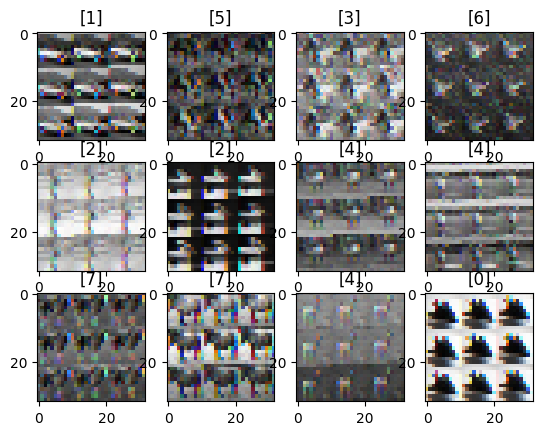

In [5]:
fig,ax = plt.subplots(3,4)
for i in range(0,3):
    for j in range(0,4):
        indice = np.random.randint(1,100, size=1)
        img = X.iloc[indice]
        title_ = Y.iloc[indice]
        img = img.values.reshape(32,32,3)
        ax[i,j].imshow(img, aspect='auto')
        ax[i,j].set_title(title_.values[0])

Create a GridSearchCV model, search for all the hyperparameters and select the best one for the model. Hyperparameters choosed are: C, Kernel, Gamma

C is the error term, Kernel is the function kernel type, and Gamma is the kernel coefficient.

grid_params -> Dict datatype, parameters used for fine tunning.
sklearn.svc.SVC -> Model used.
sklearn.model_selection.GridSearchCV.fit -> Used to fit the data and train the model.



In [ ]:
grid_params = {
    'C':[0.01, 0.1, 1],
    'kernel':['linear'],
    'gamma':['scale', 'auto']
}

model = SVC()

grid_search = GridSearchCV(model, grid_params)

grid_search.fit(x_train,y_train)

/home/filipy/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
